<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
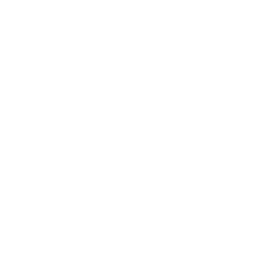
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Dokumentation av schema för genomisk variantannotering</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioinformatik / Datahantering för klinisk genomik &nbsp;|&nbsp; mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Dokumentera schemat för VCF-liknande dataset med variantannotering som används i en klinisk genomikpipeline. Använd PROC CONTENTS för att katalogisera alla annoteringsfält — genomiska koordinater, allelfrekvenser, förutsagda funktionella effekter, ClinVar-klassificeringar och kvalitetsmått — och säkerställ att efterföljande verktyg för ACMG-varianttolkning tar emot korrekt typade och etiketterade indata. Ungefär 5 000 variantposter med 20+ annoteringskolumner granskas för schemaintegritet före överlämning till pipelinen.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | VCF-härledda annoterade varianter | ~5 000 |
| GENE_PANEL | Definitioner av målgenpanel | ~150 gener |
| QUALITY_METRICS | Sekvenserings-QC per prov | ~50 prov |

---

In [1]:
/* --------------------------------------------------------
   Generera VCF-liknande dataset för variantannotering
   5 000 varianter med kliniska annoteringsfält
   -------------------------------------------------------- */
data variant_annotations;
    CALL streaminit(42);
    LÄNGD variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    ETIKETT variant_id='Variantidentifierare'
          chromosome='Kromosom'
          position='Genomisk position (GRCh38)'
          ref_allele='Referensallel'
          alt_allele='Alternativ allel'
          gene_symbol='HGNC-gensymbol'
          transcript_id='Ensembl-transkript-ID'
          consequence='Sekvensontologi-konsekvens'
          impact='Förutsagd påverkansnivå'
          hgvs_c='HGVS-kodningsnotation'
          hgvs_p='HGVS-proteinnotation'
          gnomad_af='gnomAD-allelfrekvens'
          clinvar_class='ClinVar-klassificering'
          clinvar_id='ClinVar-accession'
          sift_score='SIFT-poäng'
          sift_pred='SIFT-förutsägelse'
          polyphen_score='PolyPhen-2-poäng'
          polyphen_pred='PolyPhen-2-förutsägelse'
          cadd_phred='CADD-Phred-poäng'
          revel_score='REVEL-ensemblepoäng'
          genotype='Provgenotyp'
          allele_depth='Alternativt alleldjup'
          read_depth='Totalt läsdjup'
          qual_score='Variantkvalitetspoäng'
          filter_status='Filterstatus';
    FÄLT genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    FÄLT conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    FÄLT impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    FÄLT cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    FÄLT refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    FÄLT gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    GÖR i = 1 TILL 5000;
        variant_id = cat('VAR-', SKRIV_UT_V(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', SKRIV_UT_V(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', SKRIV_UT_V(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', SKRIV_UT_V(codon_pos, 4.), ref_allele, '>', alt_allele);
        OM c_idx <= 2 SÅ
            hgvs_p = cat('p.', SKRIV_UT_V(int(rand('uniform') * 800) + 1, 4.));
        ANNARS hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', SKRIV_UT_V(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        OM sift_score < 0.05 SÅ sift_pred = 'DELETERIOUS';
        ANNARS sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        OM polyphen_score > 0.908 SÅ polyphen_pred = 'PROB_DAMAGING';
        ANNARS OM polyphen_score > 0.446 SÅ polyphen_pred = 'POSS_DAMAGING';
        ANNARS polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        UTDATA;
    SLUT;
    TA_BORT i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
KÖR;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.05 seconds
  cpu   3.05 seconds


In [2]:
/* --------------------------------------------------------
   Generera definitioner av målgenpanel
   -------------------------------------------------------- */
data gene_panel;
    CALL streaminit(42);
    LÄNGD gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    ETIKETT gene_symbol='HGNC-gensymbol'
          gene_name='Fullständigt gennamn'
          chromosome='Kromosom'
          start_pos='Genstartposition'
          end_pos='Genslutposition'
          panel_name='Klinisk genpanel'
          disease_association='Associerad sjukdom'
          inheritance='Nedärvningsmönster';
    FÄLT genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    FÄLT gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    FÄLT diseases[15] $50 _temporary_ (
        'Ärftlig bröst-/äggstockscancer'
        'Ärftlig bröst-/äggstockscancer'
        'Li-Fraumenis syndrom'
        'Icke-småcellig lungcancer'
        'Kolorektalcancer'
        'Bröstcancer'
        'Cowdens syndrom'
        'Familjär adenomatös polypos'
        'Lynchs syndrom'
        'Lynchs syndrom'
        'Ataxia-telangiektasi'
        'Li-Fraumenis syndrom'
        'Ärftlig bröstcancer'
        'Ärftlig bröst-/äggstockscancer'
        'Ärftlig bröst-/äggstockscancer');
    FÄLT inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    GÖR g = 1 TILL 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', SKRIV_UT_V(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        UTDATA;
    SLUT;
    TA_BORT g chr_num;
KÖR;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Generera sekvenseringskvalitetsmått per prov
   -------------------------------------------------------- */
data quality_metrics;
    CALL streaminit(42);
    LÄNGD sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    ETIKETT sample_id='Providentifierare'
          run_id='Sekvenseringskörnings-ID'
          platform='Sekvenseringsplattform'
          mean_coverage='Medeltäckning för mål'
          pct_target_20x='Procent baser >= 20x'
          pct_target_100x='Procent baser >= 100x'
          total_variants='Totalt antal anropade varianter'
          ti_tv_ratio='Transition/transversion-kvot'
          het_hom_ratio='Het/Hom-kvot'
          contamination_est='Uppskattad kontamination'
          qc_status='QC godkänd/underkänd-status';
    GÖR s = 1 TILL 50;
        sample_id = cat('SAMP-', SKRIV_UT_V(s, z6.));
        run_id = cat('RUN-', SKRIV_UT_V(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        OM mean_coverage < 150 ELLER pct_target_20x < 95
            ELLER contamination_est > 0.015 SÅ qc_status = 'FAIL';
        ANNARS qc_status = 'PASS';
        UTDATA;
    SLUT;
    TA_BORT s;
KÖR;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                      Variantpåverkan efter ClinVar-klassificering                                      

                                                   The FREQ Procedure

Table of Förutsagd påverkansnivå by ClinVar-klassificering

Förutsagd påverkansnivå    |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
---------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                       |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                           |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                           |                 14.52 |       


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


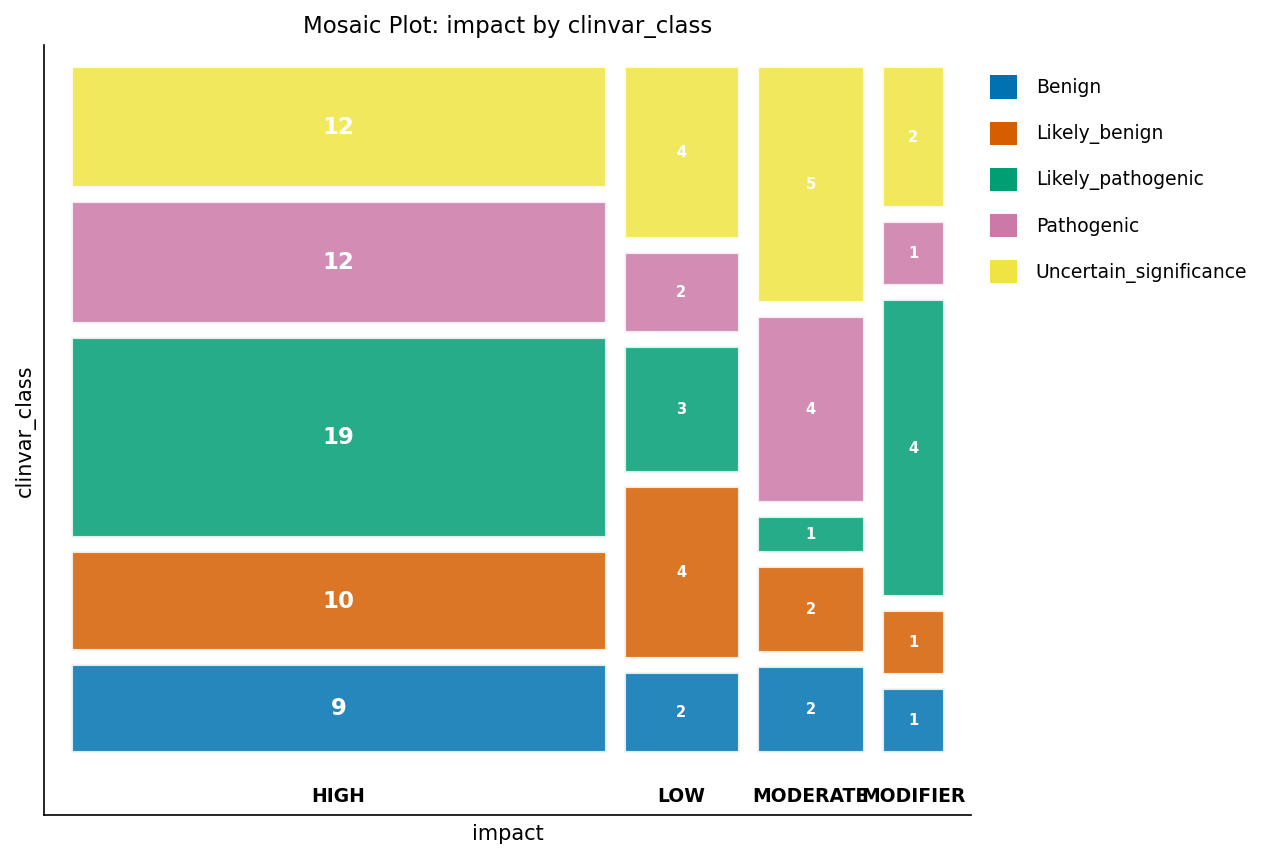

In [4]:
/* --------------------------------------------------------
   Baslinjesammanfattning av variantannotering
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    TITEL 'Variantpåverkan efter ClinVar-klassificering';
KÖR;

PROCEDUR MEDELVÄRDEN data=quality_metrics n mean MIN MAX;
    VARIABEL mean_coverage ti_tv_ratio contamination_est;
    TITEL 'Sammanfattning av sekvenseringskvalitetsmått';
KÖR;

---

                                      Sammanfattning av sekvenseringskvalitetsmått                                      

                                      Sammanfattning av sekvenseringskvalitetsmått                                      




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


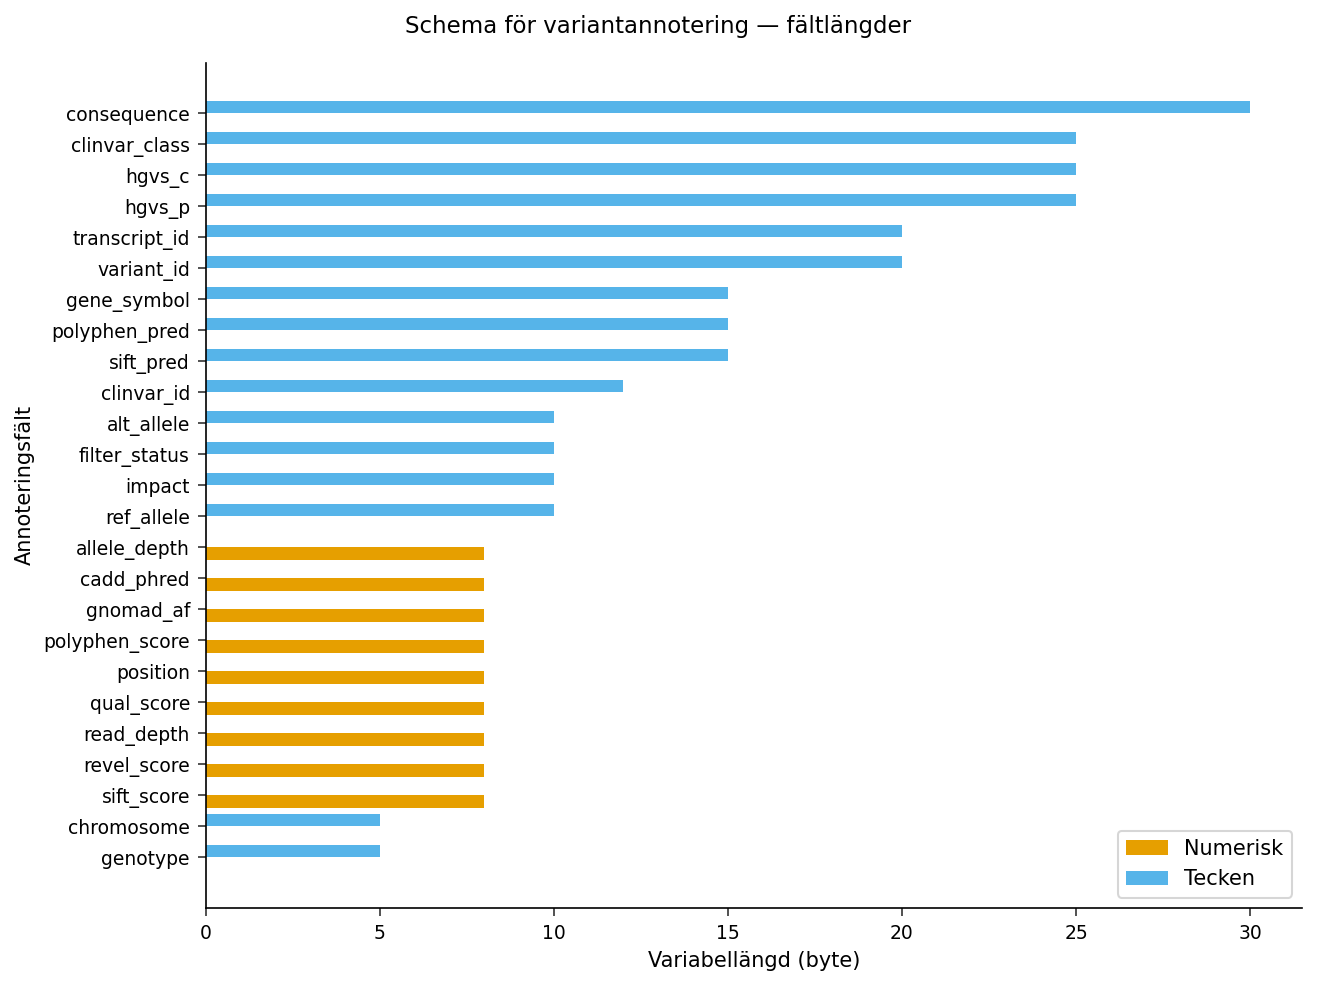

In [5]:
/* --------------------------------------------------------
   Fördelning av variabeltyp och -längd.
   Fånga schemametadatan för annoteringen med PROC
   CONTENTS OUT=, och rita sedan fältlängder per typ. TYPE-
   koder: 1 -> Numerisk, 2 -> Tecken för teckenförklaringen.
   -------------------------------------------------------- */
PROCEDUR INNEHÅLL data=variant_annotations out=schema_lengths NOPRINT;
KÖR;

data schema_lengths;
    STÄLL_IN schema_lengths;
    LÄNGD type_label $9;
    OM TYPE = 1 SÅ type_label = 'Numerisk';
    ANNARS type_label = 'Tecken';
KÖR;

PROCEDUR SGPLOT data=schema_lengths;
    HBAR NAME / RESPONSE=LENGTH GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS ETIKETT='Variabellängd (byte)';
    YAXIS ETIKETT='Annoteringsfält';
    TITEL 'Schema för variantannotering — fältlängder';
KÖR;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS: Dokumentera hela schemat för
   variantannotering — typer, längder, etiketter för alla
   25 fält. Fånga variabelmetadatan med OUT= så att
   efterföljande steg kan validera schemat programmatiskt.
   -------------------------------------------------------- */
PROCEDUR INNEHÅLL data=variant_annotations out=variant_schema NOPRINT;
KÖR;

PROCEDUR SKRIV data=variant_schema;
    VARIABEL NAME TYPE LENGTH VARNUM LABEL;
    TITEL 'Dataset för variantannotering — fullständigt schema';
KÖR;

                                      Sammanfattning av sekvenseringskvalitetsmått                                      

                                  Dataset för variantannotering — fullständigt schema                                   

  Obs            NAME  TYPE  LENGTH  VARNUM                       LABEL
    1  allele_depth       1       8      22  Alternativt alleldjup
    2  alt_allele         2      10       5  Alternativ allel
    3  cadd_phred         1       8      19  CADD-Phred-poäng
    4  chromosome         2       5       2  Kromosom
    5  clinvar_class      2      25      13  ClinVar-klassificering
    6  clinvar_id         2      12      14  ClinVar-accession
    7  consequence        2      30       8  Sekvensontologi-konsekvens
    8  filter_status      2      10      25  Filterstatus
    9  gene_symbol        2      15       6  HGNC-gensymbol
   10  genotype           2       5      21  Provgenotyp
   11  gnomad_af          1       8      12  gnomAD-allelfrek


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS: Dokumentera genpanelens schema
   -------------------------------------------------------- */
PROCEDUR INNEHÅLL data=gene_panel out=panel_schema NOPRINT;
KÖR;

PROCEDUR SKRIV data=panel_schema;
    VARIABEL NAME TYPE LENGTH VARNUM LABEL;
    TITEL 'Definition av genpanel — schema';
KÖR;

                                  Dataset för variantannotering — fullständigt schema                                   

                                            Definition av genpanel — schema                                             

  Obs                 NAME  TYPE  LENGTH  VARNUM                  LABEL
    1  chromosome              2       5       3  Kromosom
    2  disease_association     2      50       7  Associerad sjukdom
    3  end_pos                 1       8       5  Genslutposition
    4  gene_name               2      60       2  Fullständigt gennamn
    5  gene_symbol             2      15       1  HGNC-gensymbol
    6  inheritance             2       5       8  Nedärvningsmönster
    7  panel_name              2      30       6  Klinisk genpanel
    8  start_pos               1       8       4  Genstartposition




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS: Dokumentera QC-måttens schema
   -------------------------------------------------------- */
PROCEDUR INNEHÅLL data=quality_metrics out=qc_schema NOPRINT;
KÖR;

PROCEDUR SKRIV data=qc_schema;
    VARIABEL NAME TYPE LENGTH VARNUM LABEL;
    TITEL 'Sekvenseringskvalitetsmått — schema';
KÖR;

                                            Definition av genpanel — schema                                             

                                          Sekvenseringskvalitetsmått — schema                                           

  Obs               NAME  TYPE  LENGTH  VARNUM                            LABEL
    1  contamination_est     1       8      10  Uppskattad kontamination
    2  het_hom_ratio         1       8       9  Het/Hom-kvot
    3  mean_coverage         1       8       4  Medeltäckning för mål
    4  pct_target_100x       1       8       6  Procent baser >= 100x
    5  pct_target_20x        1       8       5  Procent baser >= 20x
    6  platform              2      15       3  Sekvenseringsplattform
    7  qc_status             2      10      11  QC godkänd/underkänd-status
    8  run_id                2      12       2  Sekvenseringskörnings-ID
    9  sample_id             2      15       1  Providentifierare
   10  ti_tv_ratio           1       8       8 


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   Schemavalidering: kontrollera att annoteringsfälten
   uppfyller pipelinekraven för ACMG-tolkning.
   Läser metadatan från PROC CONTENTS OUT=, där TYPE=1
   betecknar numerisk och TYPE=2 betecknar tecken.
   -------------------------------------------------------- */
data schema_validation;
    STÄLL_IN variant_schema;
    LÄNGD requirement $60 status $10;
    /* Numeriska poängfält måste lagras som numeriska (TYPE=1) */
    OM NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE ne 1 SÅ GÖR;
        requirement = 'Måste vara numerisk för poängtrösklar';
        status = 'FAIL';
    SLUT;
    ANNARS OM NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE = 1 SÅ GÖR;
        requirement = 'Numerisk typ bekräftad';
        status = 'PASS';
    SLUT;
    /* ClinVar-klassen behöver tillräcklig teckenlängd */
    ANNARS OM NAME = 'clinvar_class' AND LENGTH < 25 SÅ GÖR;
        requirement = 'Minst $25 för fullständig klassificeringstext';
        status = 'FAIL';
    SLUT;
    ANNARS OM NAME = 'clinvar_class' SÅ GÖR;
        requirement = 'Teckenlängd tillräcklig';
        status = 'PASS';
    SLUT;
    /* Alla fält måste bära en etikett för datalexikonet */
    ANNARS OM LABEL = '' SÅ GÖR;
        requirement = 'Etikett krävs för datalexikon';
        status = 'FAIL';
    SLUT;
    ANNARS GÖR;
        requirement = 'Allmän validering';
        status = 'PASS';
    SLUT;
KÖR;

PROCEDUR SKRIV data=schema_validation;
    VARIABEL NAME TYPE LENGTH LABEL requirement status;
    TITEL 'Schemavalideringsrapport för ACMG-pipeline';
KÖR;

                                       Schemavalideringsrapport för ACMG-pipeline                                       

  Obs            NAME  TYPE  LENGTH                       LABEL                requirement  status
    1  allele_depth       1       8  Alternativt alleldjup       Numerisk typ bekräftad     PASS
    2  alt_allele         2      10  Alternativ allel            Allmän validering          PASS
    3  cadd_phred         1       8  CADD-Phred-poäng            Numerisk typ bekräftad     PASS
    4  chromosome         2       5  Kromosom                    Allmän validering          PASS
    5  clinvar_class      2      25  ClinVar-klassificering      Teckenlängd tillräcklig    PASS
    6  clinvar_id         2      12  ClinVar-accession           Allmän validering          PASS
    7  consequence        2      30  Sekvensontologi-konsekvens  Allmän validering          PASS
    8  filter_status      2      10  Filterstatus                Allmän validering          PASS
   


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### Tolkning

Schemat för variantannotering innehåller 25 fält som spänner över genomiska koordinater, funktionella förutsägelser, populationsfrekvenser och kvalitetsindikatorer per prov. Alla nio numeriska poängfält (gnomAD-allelfrekvens, SIFT, PolyPhen-2, CADD, REVEL, kvalitetspoäng, alleldjup, läsdjup och genomisk position) är korrekt typade som numeriska, vilket gör att ACMG-tolkningsmotorn kan tillämpa tröskelbaserad filtrering utan typkonvertering. Fältet clinvar_class på $25 rymmer den längsta ClinVar-klassificeringssträngen (Uncertain_significance på 24 tecken). Varje annoteringsfält bär en beskrivande etikett, vilket uppfyller det kliniska laboratoriets krav på datalexikon enligt CAP-ackrediteringskraven. Genpanelschemat kartlägger 15 cancerpredisponerande gener med nedärvningsmönster och sjukdomsassociationer, vilket ger referensramen för variant-till-gen-annotering. Datasetet med sekvenserings-QC-mått dokumenterar 50 prov över 5 körningar, med kontaminationsuppskattningar och täckningströsklar som styr variantanropens tillförlitlighet. Detta dokumentationspaket för schemat stöder laboratoriets valideringsdossier för inlämningen till New York State CLEP.

---

In [10]:
/* --------------------------------------------------------
   Exportera dokumentationen av variantschemat och
   valideringsrapporten för laboratorieackreditering
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
KÖR;

PROCEDUR EXPORTERA data=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
KÖR;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>